In [79]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Load the saved file
combined = pd.read_csv("./cleaneddata/combined_events.csv")

## Visualize any missing data, and possibly impute them if they are not correlated with Attendance_Ratio

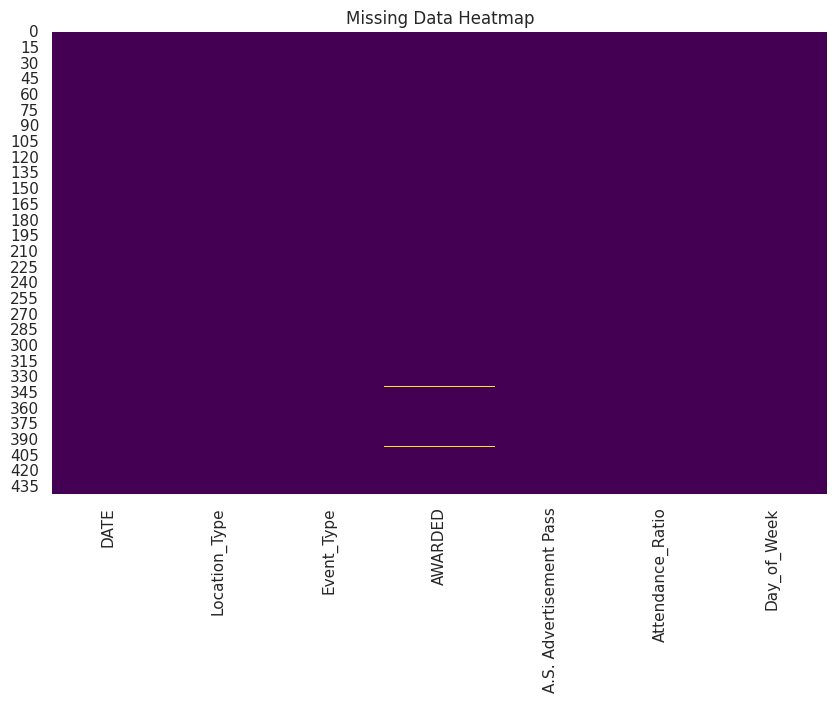

In [80]:
plt.figure(figsize=(10, 6))
sns.heatmap(combined.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()



Looks like there were only 2 missing values within AWARDED, and this could possibly explain the very high correlation coefficient with Attendance Ratio. We will impute those two missing values using median because AWARDED can span a very large range, using a mean here could possibly skew the data.

In [81]:
# Check min, max, and median
print("AWARDED range:")
print("Min:", combined['AWARDED'].min())
print("Max:", combined['AWARDED'].max())
print("Median:", combined['AWARDED'].median())

# Impute missing values with median
combined['AWARDED'] = combined['AWARDED'].fillna(combined['AWARDED'].median())

# Confirm no more missing
print("\nMissing values after imputation:", combined['AWARDED'].isnull().sum())

missing_summary = combined.isnull().sum()

print("\nMissing Value Summary:")
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

# Optionally, inspect how many rows have *any* missing entries
nan_rows = combined[combined.isnull().any(axis=1)]
print(f"\nTotal rows with at least one NaN: {len(nan_rows)}")

# (Optional) Drop rows or impute missing values if needed
# Example: fill AWARDED NaNs with median
combined['AWARDED'].fillna(combined['AWARDED'].median(), inplace=True)



AWARDED range:
Min: 10.57
Max: 10402.7
Median: 313.20000000000005

Missing values after imputation: 0

Missing Value Summary:
Series([], dtype: int64)

Total rows with at least one NaN: 0


/tmp/ipykernel_3607/781026422.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined['AWARDED'].fillna(combined['AWARDED'].median(), inplace=True)


## EDA on continous variable(Awarded)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   DATE                     442 non-null    datetime64[ns]
 1   Location_Type            442 non-null    object        
 2   Event_Type               442 non-null    object        
 3   AWARDED                  442 non-null    float64       
 4   A.S. Advertisement Pass  442 non-null    object        
 5   Attendance_Ratio         442 non-null    float64       
 6   Day_of_Week              442 non-null    object        
 7   log_Attendance_Ratio     442 non-null    float64       
 8   log_AWARDED              442 non-null    float64       
 9   Month                    442 non-null    period[M]     
dtypes: datetime64[ns](1), float64(4), object(4), period[M](1)
memory usage: 34.7+ KB


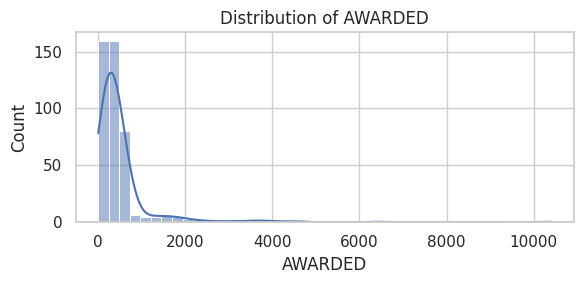

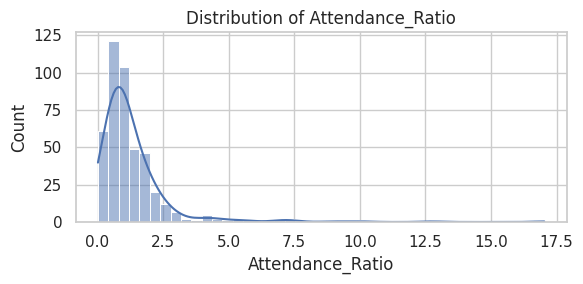

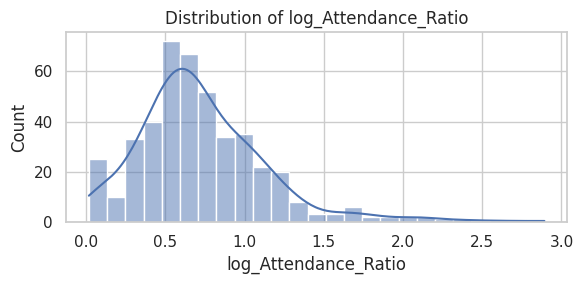

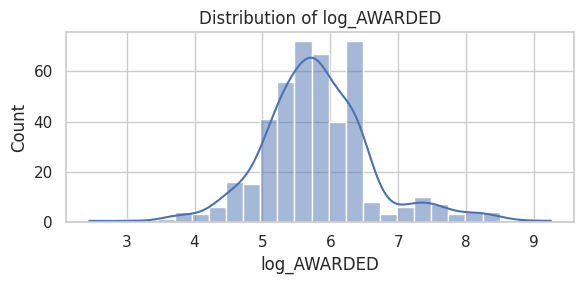

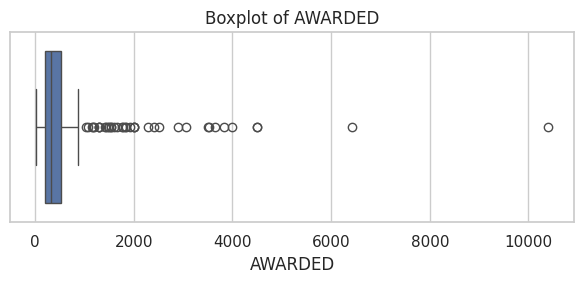

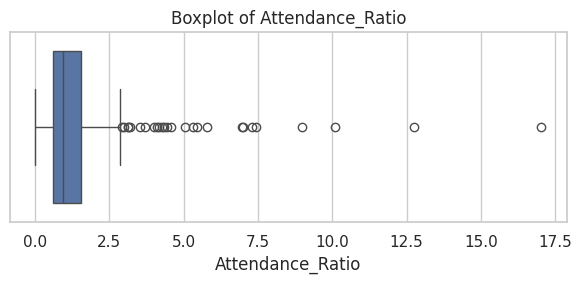

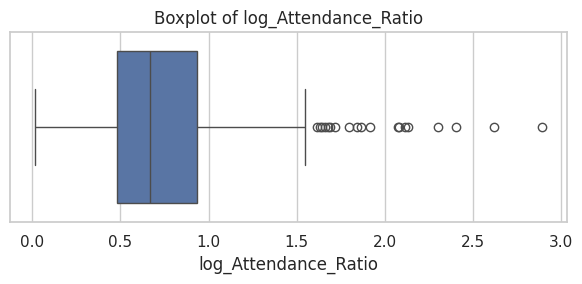

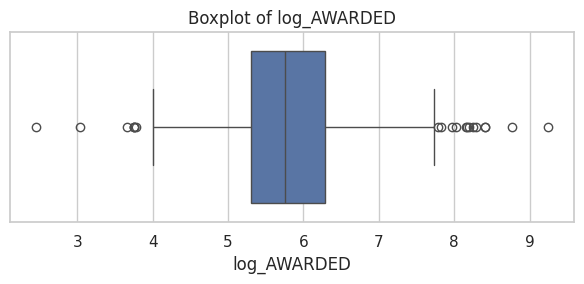

In [91]:
# Fix: the correct column name is "Attendance_Ratio", not "attendance_ratios"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlations properly
correlations = combined.corr(numeric_only=True)['Attendance_Ratio'].sort_values(ascending=False)

# EDA summary
info = combined.info()
summary = combined.describe(include='all')
missing = combined.isnull().sum().sort_values(ascending=False)

# Visualize numeric distributions
numeric_cols = combined.select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(combined[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# Boxplots for outlier inspection
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=combined[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


In [83]:

missing_summary = combined.isnull().sum()

print("\nMissing Value Summary:")
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

# Optionally, inspect how many rows have *any* missing entries
nan_rows = combined[combined.isnull().any(axis=1)]
print(f"\nTotal rows with at least one NaN: {len(nan_rows)}")



Missing Value Summary:
Series([], dtype: int64)

Total rows with at least one NaN: 0


### Looks like we have to take log for AWARDED and Attendance_Ratios to normalize the distribution, looks like AWARDED is pretty left skewed, there is also an outlier in AWARDED, with an event with a much higher funding than the rest >10000

In [84]:
# Identify outliers in AWARDED (greater than 10,000)
outliers = combined[combined['AWARDED'] > 10000]
outliers

,DATE,Location_Type,Event_Type,AWARDED,A.S. Advertisement Pass,Attendance_Ratio,Day_of_Week
436,2025-02-15,Price Center,Social,10402.7,Yes,0.9853,Saturday


In [85]:
combined['log_Attendance_Ratio'] = np.log1p(combined['Attendance_Ratio'])
combined['log_AWARDED'] = np.log1p(combined['AWARDED'])

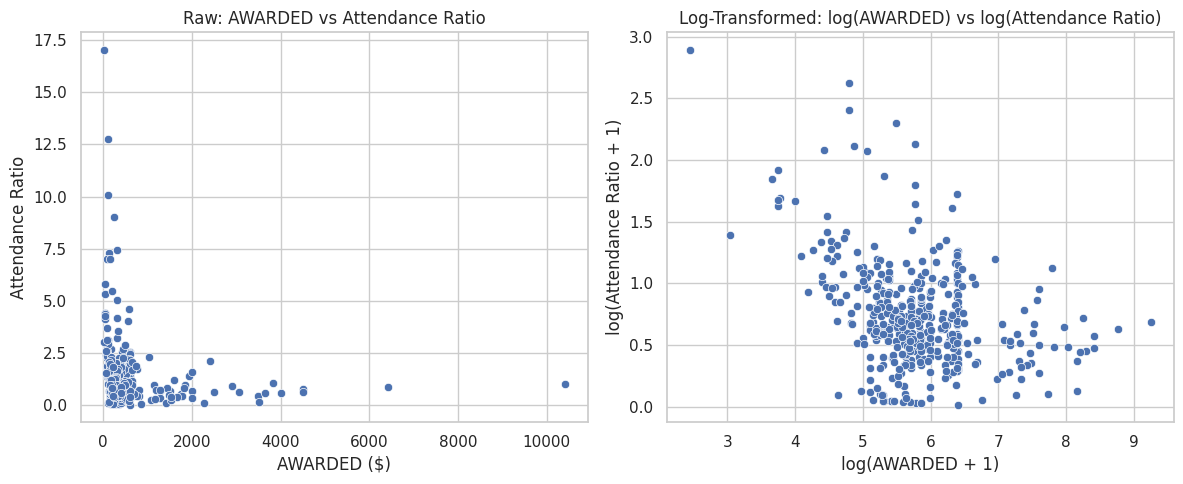

In [86]:
import numpy as np

# Ensure both log columns exist
combined['log_Attendance_Ratio'] = np.log1p(combined['Attendance_Ratio'])
combined['log_AWARDED'] = np.log1p(combined['AWARDED'])

# Plot 1: AWARDED vs Attendance_Ratio (log vs raw)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='AWARDED', y='Attendance_Ratio', data=combined, ax=axes[0])
axes[0].set_title("Raw: AWARDED vs Attendance Ratio")
axes[0].set_xlabel("AWARDED ($)")
axes[0].set_ylabel("Attendance Ratio")

sns.scatterplot(x='log_AWARDED', y='log_Attendance_Ratio', data=combined, ax=axes[1])
axes[1].set_title("Log-Transformed: log(AWARDED) vs log(Attendance Ratio)")
axes[1].set_xlabel("log(AWARDED + 1)")
axes[1].set_ylabel("log(Attendance Ratio + 1)")

plt.tight_layout()
plt.show()



# EDA on Time Related Variables

/tmp/ipykernel_3607/3699598037.py:30: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


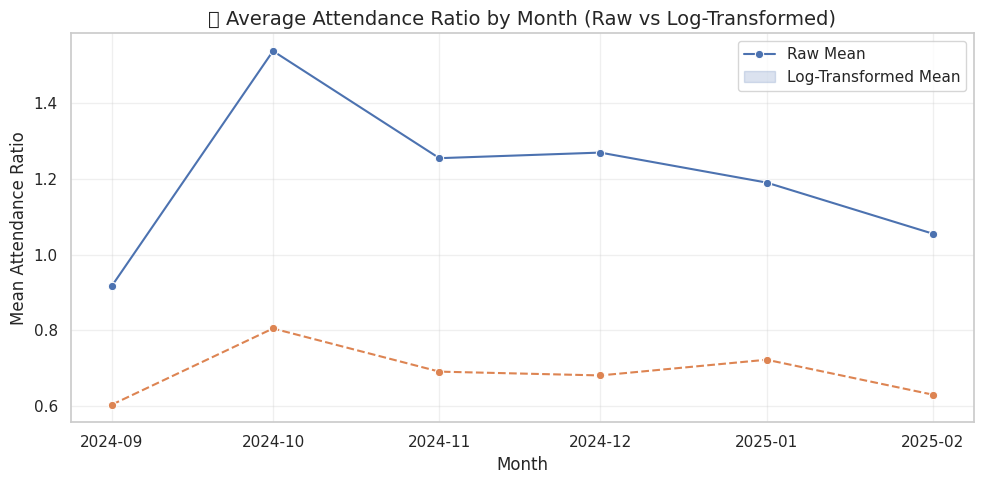

,Month,Attendance_Ratio,log_Attendance_Ratio
0,2024-09-01,0.918136,0.603764
1,2024-10-01,1.538343,0.804948
2,2024-11-01,1.255082,0.690840
3,2024-12-01,1.269840,0.680802
4,2025-01-01,1.190569,0.722330
5,2025-02-01,1.055372,0.629861


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure DATE is in datetime format
combined['DATE'] = pd.to_datetime(combined['DATE'])

# Create month column (e.g., "2024-10")
combined['Month'] = combined['DATE'].dt.to_period('M')

# Compute monthly averages for both raw and log-transformed ratios
monthly_avg = (
    combined.groupby('Month', as_index=False)
    .agg({'Attendance_Ratio': 'mean', 'log_Attendance_Ratio': 'mean'})
)

# Convert Month period to timestamp for plotting
monthly_avg['Month'] = monthly_avg['Month'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(x='Month', y='Attendance_Ratio', data=monthly_avg, marker='o')
sns.lineplot(x='Month', y='log_Attendance_Ratio', data=monthly_avg, marker='o', linestyle='--')

plt.title("📅 Average Attendance Ratio by Month (Raw vs Log-Transformed)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Mean Attendance Ratio")
plt.legend(["Raw Mean", "Log-Transformed Mean"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display the summary table for reference
display(monthly_avg)

Attendance peaked sharply in October 2024 and then gradually declined through Winter 2025, reflecting strong early-quarter engagement that tapered off later.
The log-transformed trend confirms this pattern while smoothing out the impact of a few unusually high-attendance events.

## EDA on Categorical Variables

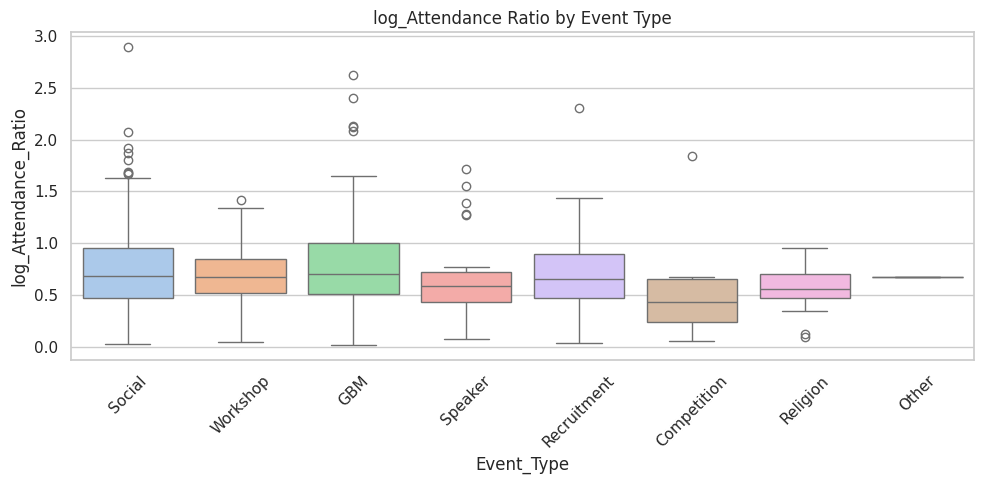

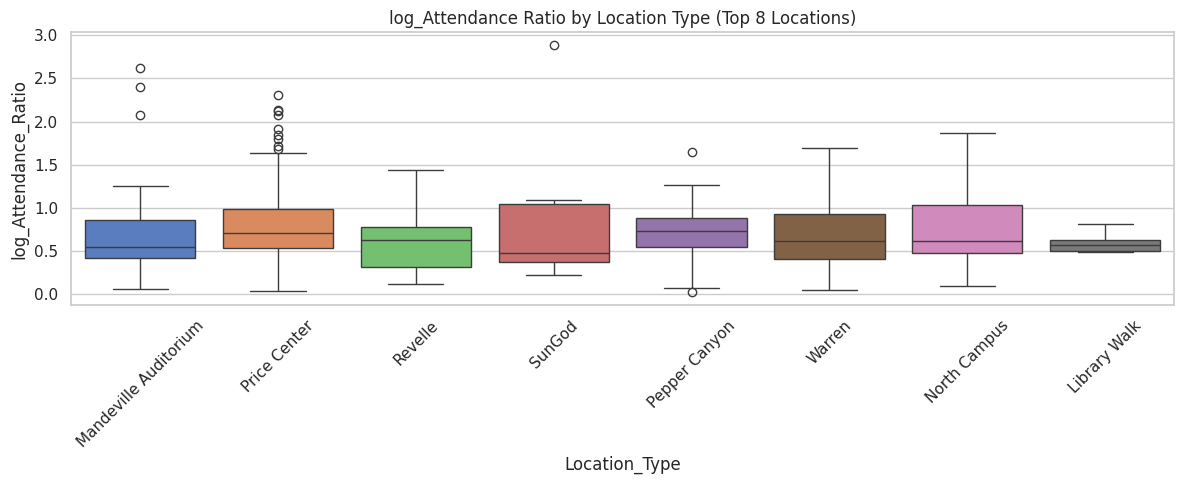

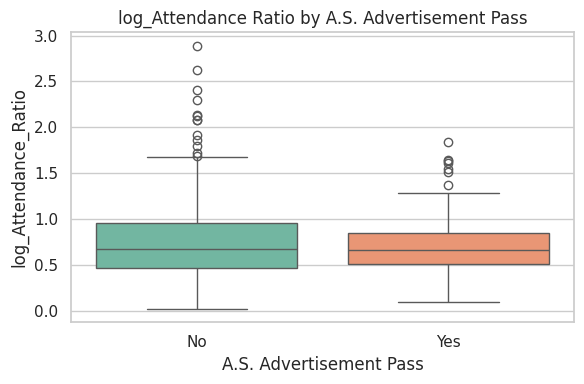

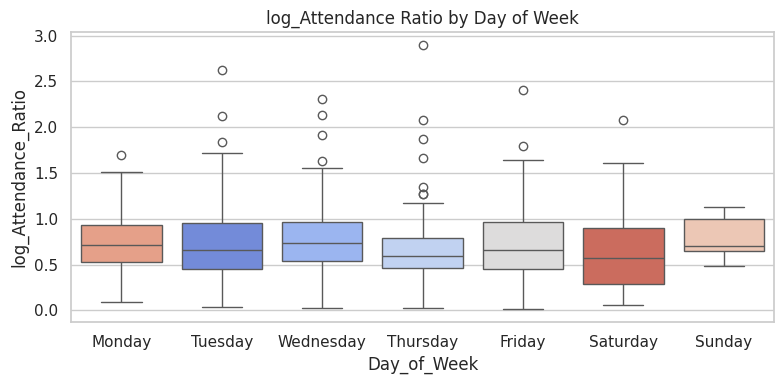

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Attendance Ratio by Event_Type
plt.figure(figsize=(10, 5))
sns.boxplot(x='Event_Type', y='log_Attendance_Ratio', hue='Event_Type',
            data=combined, palette='pastel', legend=False)
plt.title("log_Attendance Ratio by Event Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Attendance Ratio by Location_Type
plt.figure(figsize=(12, 5))
top_locations = combined['Location_Type'].value_counts().index[:8]
sns.boxplot(x='Location_Type', y='log_Attendance_Ratio', hue='Location_Type',
            data=combined[combined['Location_Type'].isin(top_locations)],
            palette='muted', legend=False)
plt.title("log_Attendance Ratio by Location Type (Top 8 Locations)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Attendance Ratio by A.S. Advertisement Pass
plt.figure(figsize=(6, 4))
sns.boxplot(x='A.S. Advertisement Pass', y='log_Attendance_Ratio',
            hue='A.S. Advertisement Pass', data=combined,
            palette='Set2', legend=False)
plt.title("log_Attendance Ratio by A.S. Advertisement Pass")
plt.tight_layout()
plt.show()

# 4. Attendance Ratio by Day_of_Week
plt.figure(figsize=(8, 4))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='Day_of_Week', y='log_Attendance_Ratio', hue='Day_of_Week',
            data=combined, order=order, palette='coolwarm', legend=False)
plt.title("log_Attendance Ratio by Day of Week")
plt.tight_layout()
plt.show()


Across all categorical dimensions, the log-transformed attendance ratio remains relatively stable but with meaningful variation across groups.
- Social and GBM events show the highest median attendance, while Recruitment and Workshop events trail slightly behind.
- Central venues such as Price Center, SunGod, and North Campus have wider spreads and higher attendance than smaller locations like Revelle or Library Walk.
- Events without A.S. Advertisement Passes tend to display greater variability and more upper outliers, suggesting other outreach methods might be effective.
- By weekday, attendance is fairly even, though Monday–Wednesday events maintain slightly higher medians compared to late-week sessions.

In [89]:

missing_summary = combined.isnull().sum()

print("\nMissing Value Summary:")
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

# Optionally, inspect how many rows have *any* missing entries
nan_rows = combined[combined.isnull().any(axis=1)]
print(f"\nTotal rows with at least one NaN: {len(nan_rows)}")

# (Optional) Drop rows or impute missing values if needed
# Example: fill AWARDED NaNs with median
combined['AWARDED'].fillna(combined['AWARDED'].median(), inplace=True)



Missing Value Summary:
Series([], dtype: int64)

Total rows with at least one NaN: 0


/tmp/ipykernel_3607/2177110586.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined['AWARDED'].fillna(combined['AWARDED'].median(), inplace=True)


In [90]:
combined.to_csv("./finaldata/combined_events.csv", index=False)